# CLIP Captioning mit RSA-basiertem pragmatischem Decoding 
## von Hannes Gröner 
### Code abgewandelt von https://github.com/rmokady/CLIP_prefix_caption/tree/main/notebooks

In [1]:
#@title Imports
import pandas as pd
import clip
import os
from torch import nn
import numpy as np
import torch
import torch.nn.functional as nnf
import sys
from typing import Tuple, List, Union, Optional
from transformers import GPT2Tokenizer, GPT2LMHeadModel, get_linear_schedule_with_warmup
from tqdm.notebook import tqdm, trange
#from google.colab import files
import skimage.io as io
import PIL.Image
from IPython.display import Image 
import matplotlib.pyplot as plt

import itertools
#import functools
import random as rd
import gdown
import json
import nltk
import re 
#from wordfreq import word_frequency
#from sklearn.model_selection import train_test_split 
import random as rd
import itertools 

sys.path.insert(1, './cider/')
from cidereval import eval_cider

#nltk.download()
content_tags = ["JJ", "JJR", "JJS", "NN", "NNS", "NNP", "NNPS", "RB" , "RBR", "RBS", "VB", 
                "VBD", "VBG", "VBN", "VBP", "VBZ"]

N = type(None)
V = np.array
ARRAY = np.ndarray
ARRAYS = Union[Tuple[ARRAY, ...], List[ARRAY]]
VS = Union[Tuple[V, ...], List[V]]
VN = Union[V, N]
VNS = Union[VS, N]
T = torch.Tensor
TS = Union[Tuple[T, ...], List[T]]
TN = Optional[T]
TNS = Union[Tuple[TN, ...], List[TN]]
TSN = Optional[TS]
TA = Union[T, ARRAY]


D = torch.device
CPU = torch.device('cpu')


def get_device(device_id: int) -> D:
    if not torch.cuda.is_available():
        return CPU
    device_id = min(torch.cuda.device_count() - 1, device_id)
    return torch.device(f'cuda:{device_id}')


CUDA = get_device

current_directory = os.getcwd()
save_path = os.path.join(os.path.dirname(current_directory), "pretrained_models")
os.makedirs(save_path, exist_ok=True)
model_path = os.path.join(save_path, 'conceptual_weights.pt')
eval_model_path = os.path.join(save_path, 'coco_weights.pt')



In [2]:
#@title Model

class MLP(nn.Module):

    def forward(self, x: T) -> T:
        return self.model(x)

    def __init__(self, sizes: Tuple[int, ...], bias=True, act=nn.Tanh):
        super(MLP, self).__init__()
        layers = []
        for i in range(len(sizes) -1):
            layers.append(nn.Linear(sizes[i], sizes[i + 1], bias=bias))
            if i < len(sizes) - 2:
                layers.append(act())
        self.model = nn.Sequential(*layers)


class ClipCaptionModel(nn.Module):

    #@functools.lru_cache #FIXME
    def get_dummy_token(self, batch_size: int, device: D) -> T:
        return torch.zeros(batch_size, self.prefix_length, dtype=torch.int64, device=device)

    def forward(self, tokens: T, prefix: T, mask: Optional[T] = None, labels: Optional[T] = None):
        embedding_text = self.gpt.transformer.wte(tokens)
        prefix_projections = self.clip_project(prefix).view(-1, self.prefix_length, self.gpt_embedding_size)
        #print(embedding_text.size()) #torch.Size([5, 67, 768])
        #print(prefix_projections.size()) #torch.Size([5, 1, 768])
        embedding_cat = torch.cat((prefix_projections, embedding_text), dim=1)
        if labels is not None:
            dummy_token = self.get_dummy_token(tokens.shape[0], tokens.device)
            labels = torch.cat((dummy_token, tokens), dim=1)
        out = self.gpt(inputs_embeds=embedding_cat, labels=labels, attention_mask=mask)
        return out

    def __init__(self, prefix_length: int, prefix_size: int = 512):
        super(ClipCaptionModel, self).__init__()
        self.prefix_length = prefix_length
        self.gpt = GPT2LMHeadModel.from_pretrained('gpt2')
        self.gpt_embedding_size = self.gpt.transformer.wte.weight.shape[1]
        if prefix_length > 10:  # not enough memory
            self.clip_project = nn.Linear(prefix_size, self.gpt_embedding_size * prefix_length)
        else:
            self.clip_project = MLP((prefix_size, (self.gpt_embedding_size * prefix_length) // 2, self.gpt_embedding_size * prefix_length))


class ClipCaptionPrefix(ClipCaptionModel):

    def parameters(self, recurse: bool = True):
        return self.clip_project.parameters()

    def train(self, mode: bool = True):
        super(ClipCaptionPrefix, self).train(mode)
        self.gpt.eval()
        return self

In [3]:
#model_path ="/home/user/Documents/Projekt_Sprachgenerierung/pretrained_models/model_weights.pt"

In [4]:
#@title GPU/CPU
is_gpu = True #@param {type:"boolean"}  

In [5]:
#@title CLIP model + GPT2 tokenizer

device = CUDA(0) if is_gpu else "cpu"
clip_model, preprocess = clip.load("ViT-B/32", device=device, jit=False)
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

In [6]:
#@title Choose pretrained model - COCO or Coneptual captions

download_model = False 

pretrained_model = 'Conceptual captions'  # @param ['COCO', 'Conceptual captions']
if download_model: 
    if pretrained_model == 'Conceptual captions':
        gdown.download(id="14pXWwB4Zm82rsDdvbGguLfx9F8aM7ovT", output=model_path, quiet=False)
        #downloader.download_file("14pXWwB4Zm82rsDdvbGguLfx9F8aM7ovT", model_path)
    else:
        downloader.download_file("1IdaBtMSvtyzF0ByVaBHtvM0JYSXRExRX", model_path)

In [7]:
#@title Choose pretrained model - COCO or Coneptual captions

download_eval_model = False 

pretrained_eval_model = 'COCO'  # @param ['COCO', 'Conceptual captions']
if download_eval_model: 
    if pretrained_eval_model == 'Conceptual captions':
        gdown.download(id="14pXWwB4Zm82rsDdvbGguLfx9F8aM7ovT", output=model_path, quiet=False)
        #downloader.download_file("14pXWwB4Zm82rsDdvbGguLfx9F8aM7ovT", model_path)
    else:
        #downloader.download_file("1IdaBtMSvtyzF0ByVaBHtvM0JYSXRExRX", model_path)
        gdown.download(id="1IdaBtMSvtyzF0ByVaBHtvM0JYSXRExRX", output=eval_model_path, quiet=False)


In [8]:
#@title Load model weights

prefix_length = 10

model = ClipCaptionModel(prefix_length)

model.load_state_dict(torch.load(model_path, map_location=CPU)) 

model = model.eval() 
device = CUDA(0) if is_gpu else "cpu"
model = model.to(device)


In [9]:
#@title Load eval model weights

prefix_length = 10

eval_model = ClipCaptionModel(prefix_length)

eval_model.load_state_dict(torch.load(eval_model_path, map_location=CPU)) 

eval_model = eval_model.eval() 
device = CUDA(0) if is_gpu else "cpu"
eval_model = eval_model.to(device)


## generation

In [10]:
# get clip prefix embedding from image path 
def preproc_img(path, proj_model=model, prefix_length = 10, d=False, resize_tuna=False):
    # read image using scikit-image
    img = io.imread(path)
    # convert to PIL format 
    pil_img = PIL.Image.fromarray(img)
    if resize_tuna:
        pil_img=resize(pil_img, max_w, max_h)
    # image is printed based on boolean value of d 
    if d:
        display(pil_img)
    # preprocess image using CLIP 
    pil_img = preprocess(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        # extract CLIP prefix embedding
        prefix = clip_model.encode_image(pil_img).to(device, dtype=torch.float32)
        prefix_embed = proj_model.clip_project(prefix).reshape(1, prefix_length, -1)
    return prefix_embed

In [11]:
#@title Caption prediction

def generate_beam(model, tokenizer, beam_size: int = 5, prompt=None, embed=None,
                  entry_length=67, temperature=1., stop_token: str = '.'):

    model.eval()
    stop_token_index = tokenizer.encode(stop_token)[0]
    tokens = None
    scores = None
    device = next(model.parameters()).device
    seq_lengths = torch.ones(beam_size, device=device)
    is_stopped = torch.zeros(beam_size, device=device, dtype=torch.bool)
    with torch.no_grad():
        if embed is not None:
            generated = embed
        else:
            if tokens is None:
                tokens = torch.tensor(tokenizer.encode(prompt))
                tokens = tokens.unsqueeze(0).to(device)
                generated = model.gpt.transformer.wte(tokens)
        for i in range(entry_length):
            outputs = model.gpt(inputs_embeds=generated)
            logits = outputs.logits
            logits = logits[:, -1, :] / (temperature if temperature > 0 else 1.0)
            logits = logits.softmax(-1).log()
            if scores is None:
                scores, next_tokens = logits.topk(beam_size, -1)
                generated = generated.expand(beam_size, *generated.shape[1:])
                next_tokens, scores = next_tokens.permute(1, 0), scores.squeeze(0)
                if tokens is None:
                    tokens = next_tokens
                else:
                    tokens = tokens.expand(beam_size, *tokens.shape[1:])
                    tokens = torch.cat((tokens, next_tokens), dim=1)
            else:
                logits[is_stopped] = -float(np.inf)
                logits[is_stopped, 0] = 0
                scores_sum = scores[:, None] + logits
                seq_lengths[~is_stopped] += 1
                scores_sum_average = scores_sum / seq_lengths[:, None]
                scores_sum_average, next_tokens = scores_sum_average.view(-1).topk(beam_size, -1)
                next_tokens_source = next_tokens // scores_sum.shape[1]
                seq_lengths = seq_lengths[next_tokens_source]
                next_tokens = next_tokens % scores_sum.shape[1]
                next_tokens = next_tokens.unsqueeze(1)
                tokens = tokens[next_tokens_source]
                tokens = torch.cat((tokens, next_tokens), dim=1)
                generated = generated[next_tokens_source]
                scores = scores_sum_average * seq_lengths
                is_stopped = is_stopped[next_tokens_source]
            next_token_embed = model.gpt.transformer.wte(next_tokens.squeeze()).view(generated.shape[0], 1, -1)
            generated = torch.cat((generated, next_token_embed), dim=1)
            is_stopped = is_stopped + next_tokens.eq(stop_token_index).squeeze()
            if is_stopped.all():
                break
    scores = scores / seq_lengths
    output_list = tokens.cpu().numpy()
    output_texts = [tokenizer.decode(output[:int(length)]) for output, length in zip(output_list, seq_lengths)]
    order = scores.argsort(descending=True)
    output_texts = [output_texts[i] for i in order]
    return output_texts


def generate2(
        model,
        tokenizer,
        df,
        entry_count=1,
        entry_length=67,  # maximum number of words
        stop_token: str = '.',
        image_path = "./data/AbstractScenes_v1.1/RenderedScenes/",
        d=False
):
    model.eval()
    generated_num = 0
    generated_list = []
    stop_token_index = tokenizer.encode(stop_token)[0]
    filter_value = -float("Inf")
    device = next(model.parameters()).device

    with torch.no_grad():
        for file in tqdm(list(df["file"]), desc="generating captions..."):
            for entry_idx in range(entry_count):
                tokens = None
                embed = preproc_img(image_path + file, d=d)

                if embed is not None:
                    generated = embed

                for i in range(entry_length):

                    outputs = model.gpt(inputs_embeds=generated)
                    logits = outputs.logits
                    logits = logits[:, -1, :]

                    next_token = torch.argmax(logits, -1).unsqueeze(0)
                    next_token_embed = model.gpt.transformer.wte(next_token)
                    if tokens is None:
                        tokens = next_token
                    else:
                        tokens = torch.cat((tokens, next_token), dim=1)
                    generated = torch.cat((generated, next_token_embed), dim=1)
                    if stop_token_index == next_token.item():
                        break

                output_list = list(tokens.squeeze().cpu().numpy())
                output_text = tokenizer.decode(output_list)
                generated_list.append(output_text)

    return generated_list

In [12]:
def get_logits(embeds, temperature, model=model):
    #print("embeds size: ", embeds.size())
    outputs = model.gpt(inputs_embeds=embeds)
    logits = outputs.logits
    #print("logits before temperature: ", logits.size())
    logits = logits[:, -1, :] / (temperature if temperature > 0 else 1.0)
    #print("logits after temperature: ", logits.size())
    return(logits)

In [45]:
def generate_RSA_t(
        model,
        tokenizer,
        df,
        entry_length=30,  # maximum number of words
        top_k=100,
        temperature=1.,
        stop_token: str = '.',
        a = 1,
        print_logits = False,
        t = 0.5,
        image_path = "./data/AbstractScenes_v1.1/RenderedScenes/",
        d = False,
        group_by = "scene_idx"

):
    model.eval()
    generated_num = 0
    generated_list = []
    rsa_stop_list = []
    stop_token_index = tokenizer.encode(stop_token)[0]
    #filter_value = 0
    device = next(model.parameters()).device
    
    
    with torch.no_grad():
        scenes = [scene for scene in list(df[group_by]) if not scene in ["None", None]]
        for scene in tqdm(list(set(scenes))):
            
            df_scene = df[df[group_by]==scene]
            for file in df_scene["file"]:
                
                tokens = None
                l0_prob_target = 0 
                RSA = True
                rsa_stop = None

                #dnames = ["d_" + str(num) for num in range(6)]
                target_embed = preproc_img(image_path + file, d=d, proj_model=model)
                distr_embeds = [preproc_img(image_path + img, d=d, proj_model=model) for img in list(df_scene["file"]) if not img==file]

                if not None in [target_embed] + distr_embeds:
                    # one embedding per image (1 target, 2 distractors)
                    generated_target = target_embed
                    generated_distr = distr_embeds
                else:
                    #print("Embedding missing, generation stopped!")
                    break
                image_priors = [1/(len(distr_embeds)+1) for embed in range(len(distr_embeds)+1)]
                for i in range(entry_length):
                    # get output logits for each image from gpt model
                    logits_target = get_logits(generated_target, temperature)
                    distr_logits = [get_logits(distr, temperature) for distr in generated_distr]

                    # sort token indices based on logit value 
                    _, sorted_indices_target = torch.sort(logits_target, descending=True)
                    # get top-k indices

                    top_indices = sorted_indices_target.squeeze(0)[:top_k]
                    #print("top_indices:", top_indices)

                    # set values of other tokens to - infinity 
                    top_logits_target = logits_target[:, top_indices] 
                    distr_top_logits = [logits[:, top_indices] for logits in distr_logits]

                    # apply softmax function to remaining logits
                    probabilities_target = nnf.softmax(top_logits_target, dim=-1)             
                    distr_probs = [nnf.softmax(logits, dim=-1) for logits in distr_top_logits]
                    if l0_prob_target < t: 
                        # pragmatic reasoning 
                        s0_probs = [probabilities_target] + distr_probs
                        #print("s0_probs size:", s0_probs[0].size())

                        l0_probs_no_n = [prob * image_priors[i] for i, prob in enumerate(s0_probs)]

                        l0_sum = sum(l0_probs_no_n)

                        l0_probs = [prob/l0_sum for prob in l0_probs_no_n]
                        u = [torch.log(prob) for prob in l0_probs]

                        #print("l0_probs size:", l0_probs[0].size())
                        s1_probs_no_n = [torch.exp(a*utility - -torch.log(s0_probs[i])) for i, utility in enumerate(u)]
                        s1_sum = torch.tensor([torch.sum(w) for w in s1_probs_no_n])
                        s1_probs = [s1_prob/s1_sum[i] for i, s1_prob in enumerate(s1_probs_no_n)]

                        target_probs = s1_probs[0]

                        # apply argmax function to target probabilities to extract the most probable next word 
                        next_token = torch.argmax(target_probs, -1).unsqueeze(0)
                        #print("l0_probs", l0_probs)
                        l0_prob_target = l0_probs[0][0][next_token]


                        if print_logits: 
                            print("s0_probs", s0_probs)
                            print("l0_probs before normalization", l0_probs_no_n)
                            print("l0_sum", l0_sum)
                            print("l0_probs after normalization", l0_probs)
                            print("U", u)
                            print("s1_probs before normalization", s1_probs_no_n)
                            print("s1_sum", s1_sum)
                            print("s1_probs after normalization", s1_probs)

                            print("next token index:", next_token)
                    else:
                        if RSA:
                            if t > 0:
                                if not tokens==None:
                                    if d:
                                        print("stopped RSA decoding after", tokenizer.decode(list(tokens.squeeze().cpu().numpy())))
                                else:
                                    if d: 
                                        print("stopped RSA decoding immediately.")
                                
                            rsa_stop = i 
                            RSA=False
                        # greedy decoding
                        next_token = torch.argmax(probabilities_target, -1).unsqueeze(0)

                    # extract embeddings for output word 
                    next_token_index = top_indices[next_token]
                    next_token_embed = model.gpt.transformer.wte(next_token_index)
                    if tokens == None:
                        tokens = next_token_index
                    else:
                        # add token to output
                        tokens = torch.cat((tokens, next_token_index), dim=1)
                    # add next token embedding to image embeddings for each image
                    generated_target = torch.cat((generated_target, next_token_embed), dim=1)
                    generated_distr = [torch.cat((gen, next_token_embed), dim=1) for gen in generated_distr]
                    # stop generating when the stop token is generated
                    if stop_token_index == next_token_index.item():
                        break
                # get list of generated output sequence
                output_list = list(tokens.squeeze().cpu().numpy())
                # convert token IDs to tokens 
                output_text = tokenizer.decode(output_list)
                # append output to list of output sentences
                generated_list.append((file, output_text))
                rsa_stop_list.append(rsa_stop)

    return (generated_list, rsa_stop_list)

In [14]:
def generate_beam(model, tokenizer, beam_size: int = 5, prompt=None, embed=None,
                  entry_length=67, temperature=1., stop_token: str = '.'):
    print("image embed size:", embed.shape)
    model.eval()
    stop_token_index = tokenizer.encode(stop_token)[0]
    tokens = None
    scores = None
    device = next(model.parameters()).device
    seq_lengths = torch.ones(beam_size, device=device)
    is_stopped = torch.zeros(beam_size, device=device, dtype=torch.bool)
    with torch.no_grad():
        if embed is not None:
            generated = embed
        else:
            if tokens is None:
                tokens = torch.tensor(tokenizer.encode(prompt))
                tokens = tokens.unsqueeze(0).to(device)
                generated = model.gpt.transformer.wte(tokens)
        for i in range(entry_length):
            outputs = model.gpt(inputs_embeds=generated)
            logits = outputs.logits
            print("logits size: ", logits.shape)
            logits = logits[:, -1, :] / (temperature if temperature > 0 else 1.0)
            logits = logits.softmax(-1).log()
            if scores is None:
                scores, next_tokens = logits.topk(beam_size, -1)
                generated = generated.expand(beam_size, *generated.shape[1:])
                next_tokens, scores = next_tokens.permute(1, 0), scores.squeeze(0)
                if tokens is None:
                    tokens = next_tokens
                else:
                    tokens = tokens.expand(beam_size, *tokens.shape[1:])
                    tokens = torch.cat((tokens, next_tokens), dim=1)
            else:
                logits[is_stopped] = -float(np.inf)
                logits[is_stopped, 0] = 0
                print("logits shape:", logits.shape,"scores shape:",  scores.shape)
                scores_sum = scores[:, None] + logits
                seq_lengths[~is_stopped] += 1
                scores_sum_average = scores_sum / seq_lengths[:, None]
                scores_sum_average, next_tokens = scores_sum_average.view(-1).topk(beam_size, -1)
                next_tokens_source = next_tokens // scores_sum.shape[1]
                seq_lengths = seq_lengths[next_tokens_source]
                next_tokens = next_tokens % scores_sum.shape[1]
                next_tokens = next_tokens.unsqueeze(1)
                tokens = tokens[next_tokens_source]
                tokens = torch.cat((tokens, next_tokens), dim=1)
                generated = generated[next_tokens_source]
                scores = scores_sum_average * seq_lengths
                is_stopped = is_stopped[next_tokens_source]
            next_token_embed = model.gpt.transformer.wte(next_tokens.squeeze()).view(generated.shape[0], 1, -1)
            generated = torch.cat((generated, next_token_embed), dim=1)
            print("generated_size:", generated.shape)
            is_stopped = is_stopped + next_tokens.eq(stop_token_index).squeeze()
            if is_stopped.all():
                break
    scores = scores / seq_lengths
    output_list = tokens.cpu().numpy()
    output_texts = [tokenizer.decode(output[:int(length)]) for output, length in zip(output_list, seq_lengths)]
    order = scores.argsort(descending=True)
    output_texts = [output_texts[i] for i in order]
    return output_texts

In [15]:
def rearrange_RSA(logits, distr_logits, image_priors, l0_probs_tokens = 0, top_k=100, t = 1, a=3, i = 0, RSA=True, pos = False, print_stops=False):

    # sort token indices based on logit value 
    _, sorted_indices_target = torch.sort(logits, descending=True)
    # get top-k indices
    #top_indices = sorted_indices_target.squeeze(0)[top_k+1:]
    top_indices = sorted_indices_target.squeeze(0)[:top_k]

    
    #print("logits size in function:", logits.shape)
    topk_scores, topk_tokens = logits.topk(top_k, -1)

            
    
    #print("topk_tokens:", topk_tokens.shape)
    top_logits_target = logits.gather(1, topk_tokens)

    pos_no_rsa = None 
    if pos:
        top_beam_words = [[re.sub("^ ", "", tokenizer.decode(ind)) for ind in beam] for beam in topk_tokens]
        top_beam_words_tagged = [nltk.pos_tag(top_words) for top_words in top_beam_words]
        beam_tags = [[pos for w, pos in top_words_tagged] for top_words_tagged in top_beam_words_tagged]


        c_tag_probs = 0
        nc_tag_probs = 0
        for beam_num, beam in enumerate(beam_tags): 
            for tc, tag in enumerate(beam): 
                if tag in content_tags: 
                    c_tag_probs += topk_scores[beam_num][tc]
                else:
                    nc_tag_probs += topk_scores[beam_num][tc]
        
        #print("c_tag_probs: {}\nnc_tag_probs: {}".format(c_tag_probs, nc_tag_probs))
        if c_tag_probs < nc_tag_probs: 
            RSA = False
            pos_no_rsa = i
            
                    
    #top_logits_target = logits[:, topk_tokens].squeeze(0)#.squeeze(0).squeeze(0)
    #print("size top_logits_target:", top_logits_target.shape)
    #top_logits_target = topk_scores
    distr_top_logits = [lg[:, topk_tokens].squeeze(0) for lg in distr_logits]
    lookup_l0 = torch.zeros(topk_tokens.shape[0],50257).to(device)
    # print("topk_tokens: {}\n topk_scores: {}\n, top_logits_target: {}".format(topk_tokens.shape, topk_scores.shape, top_logits_target.shape))
    #print("maximum of l0_probs:", torch.max(torch.max(l0_probs_tokens, -1)[0]))
    #print("size of l0_probs_tokens:",  l0_probs_tokens.shape)
    #top_l0_prob = torch.max(torch.max(l0_probs_tokens, -1)[0])
    top_l0_prob = torch.max(l0_probs_tokens)
    #print("top_l0_prob:", top_l0_prob)
    #print("top_l0_prob size:", top_l0_prob.shape)
    #print("top_l0_prob:", top_l0_prob)
    rsa_stop = None

    if RSA and (top_l0_prob.item() < t): 
    #if True:
        # pragmatic reasoning 
        s0_probs = torch.stack([top_logits_target] + distr_top_logits)
        #print("s0_probs:", s0_probs)
        #print("s0_probs size:", s0_probs.size())
        #l0_probs_no_n = [prob * image_priors[i] for i, prob in enumerate(s0_probs)]
        l0_probs_no_n = s0_probs * image_priors[:,None,None]

        #print("l0_probs_no_n size:", l0_probs_no_n.shape)
        l0_sum = torch.sum(l0_probs_no_n, 2)
        #print("size l0_sum:", l0_sum.shape)

        
        #l0_probs = [(prob/l0_sum).squeeze(0) for prob in l0_probs_no_n]
        #l0_probs = l0_probs_no_n/l0_sum[:,None]
        l0_probs = torch.div(l0_probs_no_n,l0_sum[:,:,None])
        #print("l0_probs size:", l0_probs.shape)
        u = torch.log(l0_probs)#[torch.log(prob) for prob in l0_probs]
        #print("u:", u.shape)

        #print("l0_probs size:", l0_probs[0].size())
        #print("-torch.log(s0_probs[i]):", [-torch.log(s0_probs[i]) for i, ut in enumerate(u)])
        s1_probs_no_n = torch.exp(a*u - -torch.log(s0_probs))
        #print(s1_probs_no_n.shape)
        #s1_probs_no_n = [torch.exp(a*utility - -torch.log(s0_probs[i])) for i, utility in enumerate(u)]
        #print("s1_probs before normalization:", s1_probs_no_n)
        #s1_sum = torch.tensor([torch.sum(w) for w in s1_probs_no_n])
        s1_sum = torch.sum(s1_probs_no_n, 2)
        #print("s1_sum size:", s1_sum.shape)
        s1_probs = torch.div(s1_probs_no_n, s1_sum[:,:,None])
        #print("s1_probs:", s1_probs)

        top_logits_target = s1_probs[0]
        #print("top_logits_target size:", top_logits_target.shape)
        #print("topk_tokens size:", topk_tokens.shape)

        # apply argmax function to target probabilities to extract the most probable next word 
        #next_token = torch.argmax(target_probs, -1).unsqueeze(0)
        #print("l0_probs", l0_probs)
        #print("target_probs", target_probs)
        #scores, next_tokens = target_probs.topk(beam_size, -1)
        #print("scores size after RSA:", scores.shape)
        #print("l0_probs_target first vector size:", l0_probs_target[0].shape)
        #print("l0_probs:", l0_probs)
        l0_probs_target = l0_probs[0]#[next_tokens]
        #print("size l0_probs_target:", l0_probs_target.shape)
        #print("l0_probs_target size:", l0_probs_target.shape)
        
        #print("lookup_l0 size:", lookup_l0.shape)
        for dim in range(lookup_l0.shape[0]):
            lookup_l0[dim][topk_tokens[dim]] = l0_probs_target[dim]
        #print("lookup_l0 size:", lookup_l0.shape)

    elif pos==False:
        if RSA == True:
            if print_stops:
                print("stopped RSA decoding after {} words with highest l0 probability = {}".format(i, top_l0_prob))
            RSA = False
            rsa_stop = i 
    
    else:
        if print_stops:
            print("RSA disabled at index {} due to POS decoding".format(i))
        # set RSA to True again to keep checking for POS at next step
        RSA = True
        
    lookup = torch.zeros(topk_tokens.shape[0], 50257).to(device)
    #print("topk_tokens size: {} \n top_logits_target size: {}".format(topk_tokens.shape, top_logits_target.shape))
    for dim in range(lookup.shape[0]):
        lookup[dim][topk_tokens[dim]] = top_logits_target[dim]
    #("lookup size:", lookup.shape)




    return(lookup, lookup_l0, RSA, rsa_stop, pos_no_rsa)




In [16]:
'''
beam_size = 5
embed= preproc_img("./data/AbstractScenes_v1.1/RenderedScenes/Scene98_4.png", proj_model=model, prefix_length = 10, d=False, resize_tuna=False)
#print("image embed size:", embed.shape)
distr_files = ["./data/AbstractScenes_v1.1/RenderedScenes/Scene98_1.png", "./data/AbstractScenes_v1.1/RenderedScenes/Scene98_2.png", "./data/AbstractScenes_v1.1/RenderedScenes/Scene98_3.png"]
distr_embeds = [preproc_img(file, proj_model=model, prefix_length = 10, d=False, resize_tuna=False) for file in distr_files]
entry_length=67
temperature=1.
stop_token = '.'
top_k = 100 
t = 1
image_priors = torch.tensor([1/4]* 4)
a = 3 
l0_probs_tokens = torch.tensor([[0]*5])
'''

def generate_beam_RSA(df, entry_length=67, temperature = 1, stop_token = ".", top_k = 100, t= 1, a=3, beam_size=5, 
                      image_path = "./data/AbstractScenes_v1.1/RenderedScenes/", d=False, pos=False, print_stops = False):
    model.eval()
    generated_num = 0
    generated_list = []
    rsa_stop_list = []
    pos_no_rsa_scene = []
    stop_token_index = tokenizer.encode(stop_token)[0]
    #filter_value = 0
    device = next(model.parameters()).device
    pos_no_rsa_sum = 0
    length_sum = 0
        
    for scene in tqdm(list(set(df["scene_idx"]))):
        
        df_scene = df[df["scene_idx"]==scene]
        for file in df_scene["file"]:
            pos_no_rsa_list = []
            tokens = None
            RSA = True

            #dnames = ["d_" + str(num) for num in range(6)]
            embed = preproc_img(image_path + file, d=d, proj_model=model)
            distr_embeds = [preproc_img(image_path + img, d=d, proj_model=model) for img in list(df_scene["file"]) if not img==file]
            image_num = len(distr_embeds) + 1 
            image_priors =  torch.tensor([1/image_num]*image_num).to(device)
            l0_probs_tokens = torch.tensor([[0]*5]).to(device)
            model.eval()
            stop_token_index = tokenizer.encode(stop_token)[0]
            scores = None
            device = next(model.parameters()).device
            seq_lengths = torch.ones(beam_size, device=device)
            is_stopped = torch.zeros(beam_size, device=device, dtype=torch.bool)
            pos_no_rsa_sent = []
            #print("seq_lenghths {}\n is stopped {}".format(seq_lengths, is_stopped))
            with torch.no_grad():
                if embed is not None:
                    generated = embed
                    generated_distr = distr_embeds
                else:
                    print("please input embeds!")
                for i in range(entry_length):
                    logits = get_logits(generated, temperature=temperature)
                    #print("logits size:", logits.shape)
                    #outputs = model.gpt(inputs_embeds=generated)
                    #distr_outputs = (model.gpt(input_embeds=distr) for distr in generated_distr)
                    #logits = outputs.logits
                    distr_logits = [get_logits(embed, temperature=temperature) for embed in generated_distr]
                    #logits = logits[:, -1, :] / (temperature if temperature > 0 else 1.0)
                    #logits = logits.softmax(-1).log()
                    logits = logits.softmax(-1)
                    #print("logits size after softmax:", logits.shape)
                    #distr_logits = [lg.softmax(-1).log() for lg in distr_logits]
                    distr_logits = [lg.softmax(-1) for lg in distr_logits]
                    if scores is None:
                        top_logits_target, l0_probs_tokens, RSA, rsa_stop, pos_no_rsa = rearrange_RSA(logits, distr_logits, image_priors, 
                                                                                                      l0_probs_tokens=l0_probs_tokens, top_k=top_k, 
                                                                                                      t=t, i =i, RSA=RSA, pos=pos, 
                                                                                                      print_stops=print_stops)
                        scores, next_tokens = top_logits_target.topk(beam_size, -1)
                        #print("l0_probs_tokens size: {}\nnext_tokens_size: {}".format(l0_probs_tokens.shape, next_tokens.shape))
                        l0_probs_tokens = l0_probs_tokens.gather(1, next_tokens)
                        #print("new l0_probs_tokens size:", l0_probs_tokens.shape)
                        scores = scores.squeeze(0)
                        #print("scores size {}\n next_tokens size {}".format(scores.shape, next_tokens.shape))
                        generated = generated.expand(beam_size, *generated.shape[1:])
                        #print("size of ggitenerated after expansion: ", generated.shape)
                        next_tokens = next_tokens.permute(1, 0)
                        #print("size of next_tokens after permute:", next_tokens.shape)
                        #next_tokens, scores = next_tokens.squeeze(0), scores.squeeze(0)
                        if tokens is None:
                            tokens = next_tokens
                        else:
                            tokens = tokens.expand(beam_size, *tokens.shape[1:])
                            tokens = torch.cat((tokens, next_tokens), dim=1)
                            #print("tokens after concatenation: ", tokens) 
                    else:



                        #topk_scores, topk_tokens = logits.topk(top_k, -1)
                        #top_logits_target = logits[:, topk_tokens].squeeze(0).squeeze(0)
                        #distr_top_logits = [lg[:, topk_tokens].squeeze(0).squeeze(0) for lg in distr_logits]
                        top_logits_target, l0_probs_tokens, RSA, rsa_stop, pos_no_rsa = rearrange_RSA(logits, distr_logits, image_priors, 
                                                                                                      l0_probs_tokens=l0_probs_tokens, top_k=top_k, t=t, 
                                                                                                      i=i, RSA=RSA, pos=pos, print_stops=print_stops)
                        top_logits_target[is_stopped] = -float(np.inf)
                        top_logits_target[is_stopped, 0] = 0
                        #scores, next_tokens = top_logits_target.topk(beam_size, -1)
                        #print(scores.shape, top_logits_target.shape)
                        #print("scores:", scores)
                        #scores_sum = torch.add(scores[0][:,None], top_logits_target)
                        scores_sum = scores[:, None] + top_logits_target
                        #print("scores_sum:", scores_sum)
                        seq_lengths[~is_stopped] += 1
                        #print("seq_lengths after adding 1", seq_lengths)
                        scores_sum_average = scores_sum / seq_lengths[:, None]
                        scores_sum_average, next_tokens = scores_sum_average.view(-1).topk(beam_size, -1)
                        #print("next_tokens:", next_tokens)
                        #print("next_tokens size:", next_tokens.shape)
                        
                        #print("scores_sum_average {}\n next_tokens after view operation {}".format(scores_sum_average, next_tokens))
                        next_tokens_source = next_tokens // scores_sum.shape[1]
                        
                        seq_lengths = seq_lengths[next_tokens_source]
                        next_tokens = next_tokens % scores_sum.shape[1]
                    
                        #print("scores_sum.shape[1]", scores_sum.shape[1])
                        next_tokens = next_tokens.unsqueeze(1)
                        #print("next_tokens:", next_tokens)
                        l0_probs_tokens = l0_probs_tokens.gather(1, next_tokens)
                        #print("next_tokens_source", next_tokens_source)
                        tokens = tokens[next_tokens_source]
                        tokens = torch.cat((tokens, next_tokens), dim=1)
                        #print("tokens after adding next_tokens", tokens)
                        generated = generated[next_tokens_source]
                        #print("size generated: ", generated.shape)
                        scores = scores_sum_average * seq_lengths
                        
                        #print("scores after multiplying by seq_lenghts", scores)
                        is_stopped = is_stopped[next_tokens_source]
                        #print("new is_stopped:", is_stopped)
                    next_token_embed = model.gpt.transformer.wte(next_tokens.squeeze()).view(generated.shape[0], 1, -1)
                    generated = torch.cat((generated, next_token_embed), dim=1)
                    #print("size of generated after adding next_token_embed", generated.shape)
                    is_stopped = is_stopped + next_tokens.eq(stop_token_index).squeeze()
                    #print("is_stopped after scanning for stop_token_index", is_stopped)
                    if rsa_stop !=None:
                        rsa_stop_list.append(rsa_stop)
                    if pos_no_rsa != None:
                        pos_no_rsa_sent.append(pos_no_rsa)
                    if is_stopped.all():
                        break
                pos_no_rsa_list.append(pos_no_rsa_sent)
                
            scores = scores / seq_lengths
            #print("final scores:", scores)
            output_list = tokens.cpu().numpy()
            output_texts = [tokenizer.decode(output[:int(length)]) for output, length in zip(output_list, seq_lengths)]
            order = scores.argsort(descending=True)
            #print("order:", order)
            output_text = [output_texts[i] for i in order][0]
            # add seq_lenght of chosen output to overall seq lengths of outputs to calculate proportion of tokens that were generated using 
            # RSA decoding later
            seq_length  =seq_lengths[order[0]]
            length_sum += seq_length
            
            generated_list.append(output_text)
            
            pos_no_rsa_output = pos_no_rsa_list[order[0]]
            pos_no_rsa_len = len(pos_no_rsa_output)
            # add number of tokens that were generated using RSA decoding to overall number 
            pos_no_rsa_sum += pos_no_rsa_len
            
            pos_no_rsa_scene.append(pos_no_rsa_output)
            
        pos_no_rsa_average = pos_no_rsa_sum/length_sum
        no_rsa_t_average = sum(rsa_stop_list)/length_sum
        
    return(generated_list, rsa_stop_list, pos_no_rsa_scene, no_rsa_t_average, pos_no_rsa_average)




In [17]:
def generate_RSA_pos(
        model,
        tokenizer,
        tokens=None,
        target_embed=None,
        distr_embeds=None,
        entry_count=1,
        entry_length=30,  # maximum number of words
        top_k=100,
        temperature=1.,
        stop_token: str = '.',
        a = 1,
        print_logits = False,
        t = 1
):
    model.eval()
    generated_num = 0
    generated_list = []
    stop_token_index = tokenizer.encode(stop_token)[0]
    filter_value = 0
    device = next(model.parameters()).device
    #l0_prob_target = 0 
    #RSA = True
    #rsa_stop = None
    rsa_idx, greedy_idx = [], []
    
    with torch.no_grad():

        for entry_idx in trange(entry_count):
            if not None in [target_embed] + distr_embeds:
                # one embedding per image (1 target, 2 distractors)
                generated_target = target_embed
                generated_distr = distr_embeds
            else:
                print("Embedding missing, generation stopped!")
                break
            image_priors = [1/(len(distr_embeds)+1) for embed in range(len(distr_embeds)+1)]
            for i in range(entry_length):
                # get output logits for each image from gpt model
                logits_target = get_logits(generated_target, temperature)
                distr_logits = [get_logits(distr, temperature) for distr in generated_distr]
                #logits_distr1 = get_logits(generated_distr1, temperature)
                #logits_distr2 = get_logits(generated_distr2, temperature)
                #print("logits target:", logits_target)
                #print("logits distr1:", logits_distr1)

                # sort token indices based on logit value 
                _, sorted_indices_target = torch.sort(logits_target, descending=True)
                # get top-k indices
                #top_indices = sorted_indices_target.squeeze(0)[top_k+1:]
                top_indices = sorted_indices_target.squeeze(0)[:top_k]
                top_words = [re.sub("^ ", "", tokenizer.decode(ind)) for ind in top_indices]
                top_words_tagged = nltk.pos_tag(top_words)
                tags = [pos for w, pos in top_words_tagged]

                
                print("tags:", top_words_tagged)

                #print("top_indices:", top_indices)

                # set values of other tokens to - infinity 
                top_logits_target = logits_target[:, top_indices] 
                distr_top_logits = [logits[:, top_indices] for logits in distr_logits]
 
                #logits_target[:, top_indices] = filter_value
                #print("logits_target: ", logits_target)
                #logits_distr1[:, top_indices] = filter_value
                #logits_distr2[:, top_indices] = filter_value

                # apply softmax function to remaining logits
                probabilities_target = nnf.softmax(top_logits_target, dim=-1)             
                distr_probs = [nnf.softmax(logits, dim=-1) for logits in distr_top_logits]
                
                c_tag_probs = 0
                nc_tag_probs = 0
                for tc, tag in enumerate(tags): 
                    if tag in content_tags: 
                        c_tag_probs += probabilities_target[0][tc]
                    else:
                        nc_tag_probs += probabilities_target[0][tc]
                
                print("c_tag_probs: {}\n nc_tag_probs: {}".format(c_tag_probs, nc_tag_probs))
                if c_tag_probs > nc_tag_probs: 
                    rsa_idx.append(i)
                    # pragmatic reasoning 
                    s0_probs = [probabilities_target] + distr_probs
                    #print("s0_probs size:", s0_probs[0].size())

                    l0_probs_no_n = [prob * image_priors[i] for i, prob in enumerate(s0_probs)]

                    l0_sum = sum(l0_probs_no_n)

                    l0_probs = [prob/l0_sum for prob in l0_probs_no_n]
                    u = [torch.log(prob) for prob in l0_probs]

                    #print("l0_probs size:", l0_probs[0].size())
                    s1_probs_no_n = [torch.exp(a*utility - -torch.log(s0_probs[i])) for i, utility in enumerate(u)]
                    s1_sum = torch.tensor([torch.sum(w) for w in s1_probs_no_n])
                    s1_probs = [s1_prob/s1_sum[i] for i, s1_prob in enumerate(s1_probs_no_n)]

                    target_probs = s1_probs[0]
                    
                    # apply argmax function to target probabilities to extract the most probable next word 
                    next_token = torch.argmax(target_probs, -1).unsqueeze(0)
                    #print("l0_probs", l0_probs)
                    #l0_prob_target = l0_probs[0][0][next_token]
                    
                    next_token_index = top_indices[next_token]
                    next_token_index = next_token_index.squeeze().cpu().numpy()
                    print("RSA decoding: next word: ", tokenizer.decode(next_token_index))

          
                    if print_logits: 
                        print("s0_probs", s0_probs)
                        print("l0_probs before normalization", l0_probs_no_n)
                        print("l0_sum", l0_sum)
                        print("l0_probs after normalization", l0_probs)
                        print("U", u)
                        print("s1_probs before normalization", s1_probs_no_n)
                        print("s1_sum", s1_sum)
                        print("s1_probs after normalization", s1_probs)

                        print("next token index:", next_token)
                else:
                    # greedy decoding
                    greedy_idx.append(i)
                    next_token = torch.argmax(probabilities_target, -1).unsqueeze(0)
                    next_token_index = top_indices[next_token]
                    next_token_index = next_token_index.squeeze().cpu().numpy()
                    print("greedy decoding: next word: ", tokenizer.decode(next_token_index))


                # extract embeddings for output word 
                next_token_index = top_indices[next_token]
                next_token_embed = model.gpt.transformer.wte(next_token_index)
                if tokens == None:
                    tokens = next_token_index
                else:
                    # add token to output
                    tokens = torch.cat((tokens, next_token_index), dim=1)
                # add next token embedding to image embeddings for each image
                generated_target = torch.cat((generated_target, next_token_embed), dim=1)
                generated_distr = [torch.cat((gen, next_token_embed), dim=1) for gen in generated_distr]
                # stop generating when the stop token is generated
                if stop_token_index == next_token_index.item():
                    break
            # get list of generated output sequence
            output_list = list(tokens.squeeze().cpu().numpy())
            # convert token IDs to tokens 
            output_text = tokenizer.decode(output_list)
            # append output to list of output sentences
            generated_list.append(output_text)

    return (generated_list, (rsa_idx, greedy_idx))

In [18]:
# select decoding method (beam search, greedy search or RSA-based search), including temperature parameter and 
# rationality parameter a (only for RSA-based search)
def generate_method(model, tokenizer, embeds, method="RSA", temperature=0.9, a=0.05, t=0.5, top_k = 100):
    if method=="beam_search":
        generated_text_prefix = generate_beam(model, tokenizer, embed=embeds[0], temperature=temperature)[0]
    elif method=="greedy":
        generated_text_prefix = generate2(model, tokenizer, embed=embeds[0], temperature=temperature)
    elif method=="nie":
        generated_text_prefix = generate_RSA_nie(model, tokenizer, target_embed=embeds[0], distr_embeds = embeds[1:],
                                                 temperature = temperature, a = a, t=t, top_k = top_k)
    elif method=="wf":
        generated_text_prefix = generate_RSA_wf(model, tokenizer, target_embed=embeds[0], distr_embeds = embeds[1:],
                                                 temperature = temperature, a = a, t=t, top_k = top_k)
    else: 
        generated_text_prefix = generate_RSA_new(model, tokenizer, target_embed=embeds[0], distr1_embed=embeds[1], distr2_embed=embeds[2], 
                                             temperature = temperature, a = a)

    return generated_text_prefix

In [19]:
def eval_informativity(caption, target_file, all_files, temperature=1, image_path = "./data/AbstractScenes_v1.1/RenderedScenes/", k=10):

    cap_tok = tokenizer.encode(caption)
    #print("cap_tok:", cap_tok)
    token_ps = []
    p = torch.tensor([1]*k)
    #target_embed = preproc_img(image_path + file, d=True)
    embeds = [preproc_img(image_path + img, d=False) for img in all_files]
    generated = embeds
    for tok in cap_tok:
        logits = [torch.softmax(get_logits(gen, temperature, model=eval_model), dim=-1) for gen in generated]

        #print(tok)
        p_tok = torch.tensor([logit[0].detach()[tok] for logit in logits])
        #p = [prob * tok_prob for prob, tok_prob in zip(p,p_tok)]

        p = p * p_tok
        token_ps.append(p_tok)

        next_token_embed = model.gpt.transformer.wte(torch.tensor(tok).to(device).unsqueeze(dim=0))
        #print("next token embed size:", next_token_embed.size())

        generated = [torch.cat((gen.squeeze(dim=0), next_token_embed)).unsqueeze(dim=0) for gen in generated]
        
    p_norm = p/torch.sum(p)
    #print("p_norm:", p_norm)
    #print(list(scene["file"]))
    top_pic = all_files[torch.argmax(p_norm)]
    pred_true = int(top_pic==target_file)
    return(p_norm, top_pic, pred_true) #probabilities for each picture, chosen picture





## Abstract Scenes 

### data preparation

In [20]:
sents_file = "./data/AbstractScenes_v1.1/SimpleSentences/SimpleSentences1_10020.txt"
sents_file2 = "./data/AbstractScenes_v1.1/SimpleSentences/SimpleSentences2_10020.txt"


def get_cap_df(sents_files, output_path="./data/AbstractScenes_v1.1/AS_caps.csv"):
    lines = []
    i = 0
    for file in sents_files:
        with open(file, "r") as f:
            for line in f.readlines():
                if re.match("^[0-9]", line):
                    #print(line)
                    line_idx, sent_idx, sent = line.split("\t")
                    sent = re.sub("( )\\n", "", sent)
                    if len(line_idx)>1: 
                        scene_idx, pic_idx = line_idx[:-1], line_idx[-1]
                    else:
                        scene_idx, pic_idx = 0, line_idx

                    lines.append({"cap_idx": i, "scene_idx": scene_idx, "pic_idx": pic_idx, 
                                "file": "Scene{}_{}.png".format(scene_idx, pic_idx),"caption": sent})
                    i += 1
    df = pd.DataFrame.from_dict(lines)
    if output_path: 
         df.to_csv(output_path)
    return(df)

df = get_cap_df([sents_file, sents_file2])
df.head()

,cap_idx,scene_idx,pic_idx,file,caption
0,0,0,0,Scene0_0.png,Jenny is upset because Mike isn't sharing the ...
1,1,0,0,Scene0_0.png,Mike is wearing sunglasses.
2,2,0,0,Scene0_0.png,Jenny is wearing a silly hat.
3,3,0,1,Scene0_1.png,Mike is wearing a hat with horns.
4,4,0,1,Scene0_1.png,Mike kicks a ball to Jenny.


In [29]:
def get_pic_df(cap_df, output_path="./data/AbstractScenes_v1.1/imagewise_df.csv"):
    scenes = list(set(cap_df["scene_idx"]))
    pic_dics = []
    for scene in tqdm(scenes): 
        df_scene = cap_df[cap_df["scene_idx"]==scene]
        for pic_idx in list(set(df_scene["pic_idx"])):
            df_pic = df_scene[df_scene["pic_idx"]==pic_idx]
            caps = {"cap" + str(i): cap for i, cap in enumerate(list(df_pic["caption"])[:6])}
            file = list(df_pic["file"])[0]
            dic ={"scene_idx": scene, "pic_idx": pic_idx, "file": file}
            dic.update(caps)
            pic_dics.append(dic)
            
    pic_df = pd.DataFrame.from_dict(pic_dics)
    if output_path:
        pic_df.to_csv(output_path)

    return(pic_df)

pic_df = get_pic_df(df)

  0%|          | 0/1002 [00:00<?, ?it/s]

In [30]:
def substitute_names(pic_df, output_path="./data/AbstractScenes_v1.1/imagewise_df_nn.csv"):
    pic_df_no_names = pic_df.copy()
    for c in range(6):
        col = "cap"+str(c)
        caps = pic_df[col]
        new_caps=[]
        for cap in caps:
            if type(cap)==str:
                cap_new = re.sub("^(M|m)ike", "The boy", cap)
                cap_new = re.sub("^(J|j)enny", "The girl", cap_new)
                cap_new = re.sub("(M|m)ike", "the boy", cap_new)
                cap_new = re.sub("(J|j)enny", "the girl", cap_new)
                
            new_caps.append(cap_new)
        pic_df_no_names[col] = new_caps
    if output_path:
        pic_df_no_names.to_csv(output_path)
    return(pic_df_no_names)

pic_df_nn = substitute_names(pic_df)

### train test split 

In [34]:
train = rd.sample(list(pic_df_nn["scene_idx"]), k=100)
train_df = pic_df_nn[pic_df_nn["scene_idx"].isin(train)]
test_df = pic_df_nn[~pic_df_nn["scene_idx"].isin(train)]

tt_folder = "./data/AbstractScenes_v1.1/processed_data/"
if not os.path.exists(tt_folder):
    os.makedirs(tt_folder)
train_df.to_csv(tt_folder + "train_df.csv")
test_df.to_csv(tt_folder + "test_df.csv")

In [41]:
#test_df = as_df[~as_df["scene_idx"].isin(set(df1["scene_idx"]))]
sample_scenes = rd.sample(list(test_df["scene_idx"]), k=100)
test_sample = test_df[test_df["scene_idx"].isin(sample_scenes)]

test_sample.head()

,scene_idx,pic_idx,file,cap0,cap1,cap2,cap3,cap4,cap5
150,360,1,Scene360_1.png,The boy and the girl are waving at the rocket.,The cat is standing by the swings.,The boy and the girl are playing ball.,The boy and the girl are playing with the ball.,The toy rocket is flying in the sky.,The cat sees the boy and the girl.
151,360,7,Scene360_7.png,There is a rocket in the sky.,The girl threw the beach ball.,The boy is by the swing set.,The girl and the boy are playing ball.,The rocket is zipping in the sky.,It is a cloudy day today.
152,360,5,Scene360_5.png,The boy and the girl are playing with the ball.,The boy is wearing a funny hat.,The girl is standing near the swings.,The boy and the girl play ball.,The boy wears a colorful cap.,The boy sees a rocket in the sky.
153,360,8,Scene360_8.png,A rocket is headed towards Mars.,The girl Throws the ball.,The boy will catch the ball.,The boy is very happy.,The girl is near the boy.,The girl s very happy.
154,360,2,Scene360_2.png,The boy and the girl are wearing glasses.,The rocket is flying into the sky.,The beach ball is between the boy and the girl.,The boy and the girl are wearing sunglasses.,They are near the slide.,The beach ball is between them.


In [96]:
def reduce_pics(df, k=3, output_path="./data/AbstractScenes_v1.1/processed_data/test_df_3samples.csv"):
    #reduced_df = pd.DataFrame(columns=df.columns)
    files = []
    scenes = list(set(df["scene_idx"]))
    for scene in scenes: 
        scene_df = df[df["scene_idx"]==scene]
        sample_pics = rd.sample(list(scene_df["pic_idx"]), k=3)
        #print(sample_pics)
        sample_files = list(scene_df[scene_df["pic_idx"].isin(sample_pics)]["file"])
        #print(len(sample_files))
        files += sample_files
        #reduced_df = pd.concat([reduced_df,scene_df[scene_df["pic_idx"].isin(sample_pics)]], ignore_index=True)
    return(df[df["file"].isin(files)])

In [88]:
def get_random_triplets(df, output_path="./data/AbstractScenes_v1.1/processed_data/test_df_random_triplets.csv", k=1000):
    pics = list(zip(list(df["file"]), list(df["scene_idx"])))
    #print("pics:", pics)
    #scenes = list(set(df["scene_idx"]))
    triplets = []
    i = 0
    #df["triplet_idx"] = [None] * len(df)

    while i < k: 
        triplet = rd.sample(pics, 3)
        pics = [pic for pic in pics if not pic[0] in [p[0] for p in triplet]]
        #print("pics num:", len(pics))
        if len(triplet) == len(set(triplet)):
            triplets.append(triplet)
            i += 1 
    
    for n, triplet in enumerate(triplets): 
        df.loc[df["file"].isin([t[0] for t in triplet]), "triplet_idx"] = n   
    if output_path:
        df.to_csv(output_path) 
    return(df)

df = pd.read_csv("./data/AbstractScenes_v1.1/processed_data/test_df.csv")

#df = get_random_triplets(df)
df_test = get_random_triplets(df, output_path=None, k=100)


In [89]:
mask = pd.notna(df_test['triplet_idx'])
df_test_triplets = df_test[mask]

In [90]:
df_test_triplets.head()

,Unnamed: 0,scene_idx,pic_idx,file,cap0,cap1,cap2,cap3,cap4,cap5,triplet_idx
4,4,0,2,Scene0_2.png,The boy kicks the soccer ball to the girl.,The girl is sad because the boy is mad.,The boy is near an apple tree.,The sun is partly behind a tree.,The boy is angrily kicking the soccer ball.,The girl is crying as she plays with the boy.,64.0
32,32,340,5,Scene340_5.png,The plane is coming in for a landing.,The bear wants the boy's pizza.,The boy will share his pizza with the bear.,The boy is very happy.,The boy is holding a pizza.,The boy is near a bear.,75.0
86,86,1001,0,Scene1001_0.png,The girl is waving her arm,the duck is watching the girl,The boy is throwing the ball,A duck is between the girl and the boy.,The boy is throwing a ball to the girl.,The girl is about to catch the ball.,41.0
101,101,274,7,Scene274_7.png,The boy and the girl are angry on the playground.,The girl kicks the bouncy bug ride.,A helicopter is flying past.,The girl is kicking the bumblebee.,The helicopter is landing.,The boy is sitting under the tree.,61.0
122,122,411,5,Scene411_5.png,The boy is wearing a blue cap.,The girl is wearing a sunglasses.,The girl and the boy are playing catch.,The girl is wearing sunglasses.,The boy is making a silly face.,The boy and the girl are playing ball.,14.0


In [72]:
reduced_df = reduce_pics(test_sample)

NameError: name 'reduce_pics' is not defined

In [98]:
reduced_df.head()

,scene_idx,pic_idx,file,cap0,cap1,cap2,cap3,cap4,cap5,CIDEr,informative
152,360,5,Scene360_5.png,The boy and the girl are playing with the ball.,The boy is wearing a funny hat.,The girl is standing near the swings.,The boy and the girl play ball.,The boy wears a colorful cap.,The boy sees a rocket in the sky.,1.670800,0.0
153,360,8,Scene360_8.png,A rocket is headed towards Mars.,The girl Throws the ball.,The boy will catch the ball.,The boy is very happy.,The girl is near the boy.,The girl s very happy.,1.693661,0.0
158,360,4,Scene360_4.png,The boy and the girl are excited.,The cat and dog came to play.,The rocket ship is blasting off.,The boy and the girl look happy.,There is a cat and dog by the swings.,There is a rocket in the sky.,1.927436,1.0
193,603,8,Scene603_8.png,There is a pie on the table.,The boy is sitting by the fire.,The girl is wearing purple glasses.,The boy builds a campfire.,The girl wears purple sunglasses.,The boy and the girl have a pie to share.,1.667252,0.0
194,603,2,Scene603_2.png,There is a pie on the picnic table.,The boy and the girl are sitting on the ground.,The is one white fluffy cloud in the sky.,The boy and the girl are happy.,The boy and the girl are sitting beside the ca...,There are two balls beside the picnic table.,2.425192,0.0


### hyperparameter tuning

In [ ]:
# hyperparameters

temp_range = [i/100 for i in list(range(60,110,10))]
#t_range = [0.5, 0.6, 0.7, 0.8]
a_range = [3,4,5]
#p_range = [i/100 for i in list(range(60,105,5))]
#print(temp_range)
combs = list(itertools.product(temp_range, a_range))
len(combs)

15

In [ ]:
# grid search

def grid_search(train_df, combs, output_dir="./data/AbstractScenes_v1.1/parameter_tuning/", result_file= "results_finetuning_nn.json", generate=True):
    os.makedirs(output_dir, exist_ok = True)
    #combs = itertools.product(temp_range, p_range)
    scores = {}
    for temp, a in tqdm(combs, total=len(list(combs))):

        key = "temp{}a{}".format(str(int(temp*100)), str(int(a)))
        if generate:
            print("generating captions with temperature={}, a={}".format(temp, a))
            caps, _ = generate_RSA_t(model, tokenizer, train_df, temperature = temp, t=1, a=a, top_k=100)
            train_df["train_cap"] = caps 
        else: 
            print("loading captions generated with temperature={}, a={}".format(temp, a))
            train_df = pd.read_csv("./data/AbstractScenes_v1.1/parameter_tuning/{}.csv".format(key))
        #train_df["informative"] = ["nan"]*len(train_df)
        
        print("evaluating scenes...")
        key = "temp{}a{}".format(str(int(temp*100)), str(int(a)))
        
        cider = eval_cider(train_df, target_dir=output_dir, pathToData = output_dir, 
                           result_file = "results_" + key +  ".json" , gen_column="train_cap")["CIDEr"]
        train_df["CIDEr"] = cider
        mean_cider = sum(cider)/len(cider)
    
        for scene in tqdm(list(set(train_df["scene_idx"]))):
            scene_df = train_df[train_df["scene_idx"]==scene]
            caps = list(scene_df["train_cap"])
            files = list(scene_df["file"])
            informative = [int(eval_informativity(cap, files[i], files)[2]) for i, cap in enumerate(caps)]
            train_df.loc[train_df.scene_idx==scene, 'informative'] = informative
    
        train_df.to_csv(output_dir + "{}.csv".format(key))
        mean_informative = sum(list(train_df['informative']))/len(train_df)
        scores[key] = (mean_cider, mean_informative)
    
    with open(output_dir + result_file, "w") as f:
        json.dump(scores, f)
    return(scores)

In [ ]:

calculate_scores = False

if calculate_scores:
    scores = grid_search(train_df, combs)
else:
    with open("./data/AbstractScenes_v1.1/parameter_tuning/results_finetuning.json", 'r') as file:
        scores = json.load(file)

In [38]:
def aggregate_scores(combs, scores, scores_path = "./data/AbstractScenes_v1.1/parameter_tuning/"):

    for temp, a in combs: 
        key = "temp{}a{}".format(str(int(temp*100)), str(int(a)))
        file =  scores_path + "{}.csv".format(key)
        df = pd.read_csv(file)
        informative = sum([int(i) for i in list(df["informative"])])/len(list(df["informative"]))
        scores[key] = (scores[key], informative)

    cider_scores = []
    inf_scores = []

    for k in scores.keys():
        temp= int(re.search("(?<=temp)\d+", k).group(0))
        a= int(re.search("(?<=a)\d", k).group(0))
        cider, inf = scores[k] 
        cider_scores.append((temp, a,cider))
        inf_scores.append((temp, a, inf))


    total_cider = sum([p[2][0] for p in cider_scores])
    total_inf = sum([p[2] for p in inf_scores])
    mean_scores = [(c[0], c[1], (c[2][0]/total_cider + i[2]/total_inf)/2) for c, i in zip(cider_scores, inf_scores)]

    return(total_cider, total_inf, mean_scores)

In [36]:
def create_figs(scores, score_type="CIDEr", target_dir="", show=True, output_path=""):
    plt.figure()

    for a in list(set([a for temp, a, mean in scores])):
        a_scores = [p for p in scores if p[1]==a]
        plt.plot([p[0] for p in a_scores], [p[2][0] for p in a_scores], label=str(a))

    plt.title("decoding parameter testing")
    plt.xlabel("temperature")
    plt.ylabel(score_type)
    plt.legend(loc="upper right", title="a")
    if show: 
        plt.show()
    if not os.path.exists(tt_folder):
        os.makedirs(tt_folder)
    if output_path:
        if not os.path.exists(tt_folder):
            os.makedirs(tt_folder)
        fname = output_path + score_type + '_scores.png'
        plt.savefig(fname)
        print("{} figure saved to {}".format(score_type, fname))

## TESTING

In [87]:
def test(df, t=1, a=3, top_k=100, temp=0.8, target_dir="./data/AbstractScenes_v1.1/testing/RSA_r3/", cname="RSA_caps", results_file="results.json",
        results_csv="RSA_caps.csv", score_file = "scores.txt", k=10, presave=True, group_by = "scene_idx", generate=True):
    os.makedirs(target_dir, exist_ok = True)
    print("generating captions with temperature={}, t={}, a={}".format(temp, t, a))
        #caps = generate2(model, tokenizer, train_df, temperature = t, top_p=p)
    if generate: 
        caps, stop_i = generate_RSA_t(model, tokenizer, df, temperature = temp, t=t, a=a, top_k=top_k, group_by=group_by)
        print("captions generated, ")
        for cap in caps: 
            df.loc[df["file"]==cap[0], cname] = cap[1] 

        if presave: 
            df.to_csv(target_dir + results_csv)
    else:
        df = pd.read_csv(target_dir + results_csv)
        
    print("evaluating scenes...")
    #df_not_empty = df.loc[type(df[cname])!=float]
    print("calculating CIDEr scores...")
    cider = eval_cider(df, target_dir=target_dir, pathToData = target_dir, 
                       result_file = results_file , gen_column=cname)["CIDEr"]
    df["CIDEr"] = cider
    mean_cider = sum(cider)/len(cider)

    print("calculating informativity scores...")
    for scene in tqdm(list(set(df[group_by]))):
        scene_df = df[df[group_by]==scene]
        caps = list(scene_df[cname])
        files = list(scene_df["file"])
        informative = [int(eval_informativity(cap, files[i], files, k=k)[2]) for i, cap in enumerate(caps)]
        df.loc[df[group_by]==scene, 'informative'] = informative

    df.to_csv(results_csv)
    mean_informative = sum(list(df['informative']))/len(df)
    
    with open(target_dir + score_file, "w") as f:
        f.write("cider: {}\ninformative: {}".format(mean_cider, mean_informative))

    return(df, (mean_cider, mean_informative))

#test_df, scores = test(test_sample)
    

In [91]:
#test_sample = pd.read_csv("./data/AbstractScenes_v1.1/testing/test_sample.csv")
test_df, scores = test(df_test_triplets, t=0, target_dir="./data/AbstractScenes_v1.1/testing/", cname="caps_RSA", presave=True,
                       results_file="results_test_RSA_random_triplets.json", results_csv="test_RSA_random_triplets.csv", 
                       score_file = "test_scores_RSA_random_triplets.txt", k=3, group_by="triplet_idx")


generating captions with temperature=0.8, t=0, a=3


  0%|          | 0/100 [00:00<?, ?it/s]

captions generated, 
evaluating scenes...
calculating CIDEr scores...


/tmp/ipykernel_2072400/3926565494.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[df["file"]==cap[0], cname] = cap[1]


calculating informativity scores...


/tmp/ipykernel_2072400/3926565494.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["CIDEr"] = cider


  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_2072400/3926565494.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[df[group_by]==scene, 'informative'] = informative


In [93]:
#test_sample = pd.read_csv("./data/AbstractScenes_v1.1/testing/test_sample.csv")
test_df, scores = test(df_test_triplets, t=1, target_dir="./data/AbstractScenes_v1.1/testing/", cname="actual_caps_RSA", presave=True,
                       results_file="results_test_actual_RSA_random_triplets.json", results_csv="test_actual_RSA_random_triplets.csv", 
                       score_file = "test_scores_actual_RSA_random_triplets.txt", k=3, group_by="triplet_idx")


generating captions with temperature=0.8, t=1, a=3


  0%|          | 0/100 [00:00<?, ?it/s]

captions generated, 
evaluating scenes...
calculating CIDEr scores...


/tmp/ipykernel_2072400/3926565494.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[df["file"]==cap[0], cname] = cap[1]


calculating informativity scores...


/tmp/ipykernel_2072400/3926565494.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["CIDEr"] = cider


  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
# results greedy captions: around 82% (t=0)
# results RSA captions: 97%

# => if this is not due to some error I made when calculating scores on scenes (or due to the small sample size), this means that while RSA DOES work, it only does on 
# dissimilar scenes, while very similar scenes (the ones that would actually need distinguishing) are not distinguished well. 


In [ ]:
#test_sample = pd.read_csv("./data/AbstractScenes_v1.1/testing/test_sample.csv")
test_df, scores = test(reduced_df, t=0, target_dir="./data/AbstractScenes_v1.1/testing/", cname="greedy_caps", presave=True,
                       results_file="results_test_greedy_r3.json", results_csv="test_greedy_r3.csv", 
                       score_file = "test_scores_greedy_r3.txt", k=3, group_by = )


### Looking at RSA generated captions

In [110]:
RSA_df = pd.read_csv("./data/AbstractScenes_v1.1/testing/test_RSA_r3.csv")
display(RSA_df)

,Unnamed: 0,scene_idx,pic_idx,file,cap0,cap1,cap2,cap3,cap4,cap5,CIDEr,informative,RSA_caps
0,152,360,5,Scene360_5.png,The boy and the girl are playing with the ball.,The boy is wearing a funny hat.,The girl is standing near the swings.,The boy and the girl play ball.,The boy wears a colorful cap.,The boy sees a rocket in the sky.,1.671589,1.0,happy girl running with a kite.
1,153,360,8,Scene360_8.png,A rocket is headed towards Mars.,The girl Throws the ball.,The boy will catch the ball.,The boy is very happy.,The girl is near the boy.,The girl s very happy.,1.704081,1.0,boy and girl playing basketball in the park.
2,158,360,4,Scene360_4.png,The boy and the girl are excited.,The cat and dog came to play.,The rocket ship is blasting off.,The boy and the girl look happy.,There is a cat and dog by the swings.,There is a rocket in the sky.,1.964548,1.0,a vector illustration of family picnic in the ...
3,193,603,8,Scene603_8.png,There is a pie on the table.,The boy is sitting by the fire.,The girl is wearing purple glasses.,The boy builds a campfire.,The girl wears purple sunglasses.,The boy and the girl have a pie to share.,1.667154,0.0,"film character, film character, film character..."
4,194,603,2,Scene603_2.png,There is a pie on the picnic table.,The boy and the girl are sitting on the ground.,The is one white fluffy cloud in the sky.,The boy and the girl are happy.,The boy and the girl are sitting beside the ca...,There are two balls beside the picnic table.,2.377239,0.0,children playing in the park vector art illust...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
286,9936,613,0,Scene613_0.png,The girl is eating a hot dog.,The boy and the girl look worried.,There are lots of things in the air.,The boy wants the hotdog that the girl has.,The airplane is flying above the boy and the g...,A large balloon is in the sky.,1.698805,1.0,a boy and a girl playing with a pumpkin.
287,9937,613,6,Scene613_6.png,The girl has a hot dog,The girl and the boy look surprised at the cat...,The girl and the boy are at the park,The girl has a hotdog,The boy and the girl are yelling.,There is an airplane in the sky.,1.931213,0.0,kids having fun on the beach vector art illust...
288,9995,644,9,Scene644_9.png,The owl is wearing glasses and holding a red s...,The bear has a bumblebee on its head.,The boy sits on a cloud and the girl dances on...,The boy is holding the burger.,The owl is wearing sun glasses.,The owl is sitting on the shovel.,1.769547,1.0,children jumping in the sun illustration.
289,9998,644,4,Scene644_4.png,The boy has a hamburger.,The girl wants the boy to play with her.,The boy has a blue hat on.,The boy is holding a burger.,The boy has a purple hat on.,The boy is very surprised.,1.667494,0.0,boy and girl playing football in the park vect...


happy girl running with a kite.


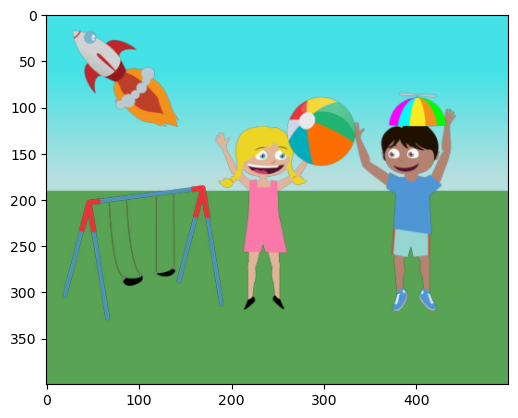

boy and girl playing basketball in the park.


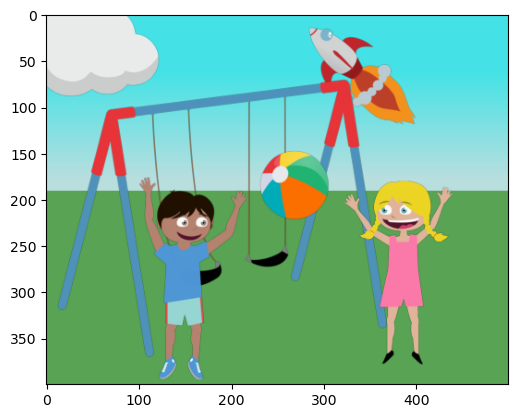

a vector illustration of family picnic in the forest.


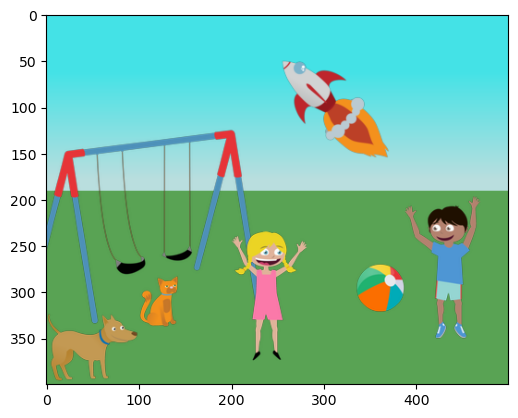

In [126]:
%matplotlib inline
from IPython.display import Image

scene1 = RSA_df[RSA_df["scene_idx"].isin([list(RSA_df["scene_idx"])[0]])]
image_path = "./data/AbstractScenes_v1.1/RenderedScenes/"
for i, row in scene1.iterrows():
    print(row["RSA_caps"])
    im = PIL.Image.open(image_path + row["file"])
    plt.imshow(im)
    plt.show() 


In [ ]:
test_df_greedy, scores_greedy = test(test_sample, t=0.5, a=3, top_k=100, temp=0.8, target_dir="./data/AbstractScenes_v1.1/testing/", cname="RSA_caps_t05", 
                       results_file="results_RSA_t05.json", results_csv="./data/AbstractScenes_v1.1/testing/RSA_caps_t05.csv", 
                       score_file = "scores_RSA_t05.txt")


In [19]:
df = pd.read_csv("./data/AbstractScenes_v1.1/testing/RSA_caps_t05.csv")
mean_informative = sum(list(df['informative']))/len(df)
cider = df["CIDEr"] 
mean_cider = sum(cider)/len(cider)
with open("./data/AbstractScenes_v1.1/testing/scores_RSA_t05.txt", "w") as f:
    f.write("cider: {}\ninformative: {}".format(mean_cider, mean_informative))

## Informativity Eval 

In [65]:
image_path = "./data/AbstractScenes_v1.1/RenderedScenes/"
temperature = 0.9

In [66]:
example_scene = df_debug[df_debug["scene_idx"]==list(df_debug["scene_idx"])[0]]

display(example_scene)

,scene_idx,pic_idx,file,cap0,cap1,cap2,cap3,cap4,cap5,caps_greedy
0,0,4,Scene0_4.png,Mike is kicking a soccer ball to Jenny.,Jenny is waiting to catch the soccer ball.,Jenny and Mike are playing ball in the sunshine.,There is a viking hat on the playground toy.,Jenny is running to get the ball from Mike.,Mike does not want to share the ball with Jenny.,kids playing soccer on the field.
1,0,7,Scene0_7.png,Mike is kicking the ball.,The dog is looking at the cat.,Jenny has her hands in the air.,Mike is kicking the soccer ball.,The cat is watching Jenny and Mike.,It is a sunny day.,children playing with a dog on the lawn.
2,0,8,Scene0_8.png,Mike is wearing glasses.,The cat is sitting by the tree.,Mike is kicking the ball.,Mike has on sunglasses.,Jenny is running to Mike.,Mike kicked the soccer ball.,children playing with a ball in the park vecto...
3,0,1,Scene0_1.png,Mike is wearing a hat with horns.,Mike kicks a ball to Jenny.,An owl sits in the tree.,Mike kicks the ball to Jenny.,Jenny will try to catch the ball.,The owl sits in the tree.,children playing soccer on the grass.
4,0,5,Scene0_5.png,Mike is wearing his new sunglasses.,Jenny is jumping up and down.,Mike and Jenny are happy in the park.,Mike has a soccer ball on his foot.,Jenny is jumping up and down.,The apples in the tree are red.,kids playing soccer on the green grass.
5,0,2,Scene0_2.png,Mike kicks the soccer ball to Jenny.,Jenny is sad because Mike is mad.,Mike is near an apple tree.,The sun is partly behind a tree.,Mike is angrily kicking the soccer ball.,Jenny is crying as she plays with Mike.,kids playing soccer on the green grass.
6,0,6,Scene0_6.png,Mike kicked the soccer ball to Jenny.,Jenny is sad because she let go of her balloons.,There is a big balloon flying across the sky.,Jenny & Mike are playing soccer together.,Jenny is crying because she doesn't like soccer.,Mike is happy to be playing with his friend Je...,children playing on the playground.
7,0,3,Scene0_3.png,The ball is up in the air.,Mike is wearing a crown.,Mike is wearing sunglasses.,Mike has a gold crown.,The soccer ball is high in the air.,Jenny is scared of the lightning.,children playing football on the grass.
8,0,9,Scene0_9.png,Mike and Jenny are playing soccer.,Mike hurt his toe when he kicked the ball.,Jenny feels badly that Mike hurt his toe.,Mike misses the ball.,Jenny runs after the ball.,Jenny yells at Mike.,kids playing football on the lawn.
9,0,0,Scene0_0.png,Jenny is upset because Mike isn't sharing the ...,Mike is wearing sunglasses.,Jenny is wearing a silly hat.,Mike is kicking the soccer ball away from Jenny.,Jenny is chasing Mike to get the ball.,Jenny is wearing a silly hat.,kids playing football on the green field.


In [71]:
probs, scene, true = eval_informativity("girl and boy playing outside.", list(example_scene["file"])[4], list(example_scene["file"]))


tensor(1.0000)


In [28]:
df_debug = pd.read_csv("/home/user/Documents/Projekt_Sprachgenerierung/project/clip_captioning_RSA/data/AbstractScenes_v1.1/df_debug.csv", index_col=0)

In [38]:
df_debug.head()

,scene_idx,pic_idx,file,cap0,cap1,cap2,cap3,cap4,cap5,cap_RSA_t
0,0,0,Scene0_0.png,Jenny is upset because Mike isn't sharing the ...,Mike is wearing sunglasses.,Jenny is wearing a silly hat.,Mike is kicking the soccer ball away from Jenny.,Jenny is chasing Mike to get the ball.,Jenny is wearing a silly hat.,funny game of tennis on the green court.
1,0,5,Scene0_5.png,Mike is wearing his new sunglasses.,Jenny is jumping up and down.,Mike and Jenny are happy in the park.,Mike has a soccer ball on his foot.,Jenny is jumping up and down.,The apples in the tree are red.,kids running around in the green grass.
2,0,3,Scene0_3.png,The ball is up in the air.,Mike is wearing a crown.,Mike is wearing sunglasses.,Mike has a gold crown.,The soccer ball is high in the air.,Jenny is scared of the lightning.,boy kicking soccer ball to the girl.
3,0,7,Scene0_7.png,Mike is kicking the ball.,The dog is looking at the cat.,Jenny has her hands in the air.,Mike is kicking the soccer ball.,The cat is watching Jenny and Mike.,It is a sunny day.,vector illustration of a woman with dog.
4,0,8,Scene0_8.png,Mike is wearing glasses.,The cat is sitting by the tree.,Mike is kicking the ball.,Mike has on sunglasses.,Jenny is running to Mike.,Mike kicked the soccer ball.,vector illustration of a family picnic in the ...


In [39]:
for scene in tqdm(list(set(df_debug["scene_idx"]))):
    scene_df = df_debug[df_debug["scene_idx"]==scene]
    caps = list(scene_df["cap_RSA_t"])
    files = list(scene_df["file"])
    informative = [int(eval_informativity(cap, files[i], files)[2]) for i, cap in enumerate(caps)]
    df_debug.loc[df_debug.scene_idx==scene, 'informative'] = informative

  0%|          | 0/3 [00:00<?, ?it/s]

In [41]:
sum([int(v) for v in df_debug["informative"]])/len(df_debug)

0.7

## aggregating scores

In [ ]:
score_list = [{"sampling": "greedy", "RSA": "no", "t": "n.a.", "POS": "n.a." , "CIDEr": 0, "informativity": 0},
              {"sampling": "greedy", "RSA": "yes", "t": "no", "POS": "no" , "CIDEr": 0, "informativity": 0},
              {"sampling": "greedy", "RSA": "yes", "t": 0.5, "POS": "no" , "CIDEr": 0, "informativity": 0},
              {"sampling": "greedy", "RSA": "yes", "t": "no", "POS": "yes" , "CIDEr": 0, "informativity": 0},
              {"sampling": "greedy", "RSA": "yes", "t": "yes", "POS": "yes" , "CIDEr": 0, "informativity": 0},
              {"sampling": "beam search", "RSA": "no", "t": "n.a.", "POS": "n.a." , "CIDEr": 0, "informativity": 0},
              {"sampling": "beam search", "RSA": "yes", "t": "no", "POS": "no" , "CIDEr": 0, "informativity": 0},
              {"sampling": "beam search", "RSA": "yes", "t": 0.5, "POS": "no" , "CIDEr": 0, "informativity": 0},
              {"sampling": "beam search", "RSA": "yes", "t": "no", "POS": "yes" , "CIDEr": 0, "informativity": 0},
              {"sampling": "beam search", "RSA": "yes", "t": 0.5, "POS": "yes" , "CIDEr": 0, "informativity": 0}]

score_df = pd.DataFrame(score_list)

## other

In [ ]:
def generate_RSA_wf(
        model,
        tokenizer,
        tokens=None,
        target_embed=None,
        distr_embeds=None,
        entry_count=1,
        entry_length=30,  # maximum number of words
        top_k=100,
        temperature=1.,
        stop_token: str = '.',
        a = 1,
        print_logits = False,
        t = 1
):
    model.eval()
    generated_num = 0
    generated_list = []
    stop_token_index = tokenizer.encode(stop_token)[0]
    filter_value = 0
    device = next(model.parameters()).device
    #l0_prob_target = 0 
    #RSA = True
    #rsa_stop = None
    rsa_idx, greedy_idx = [], []
    
    with torch.no_grad():

        for entry_idx in trange(entry_count):
            if not None in [target_embed] + distr_embeds:
                # one embedding per image (1 target, 2 distractors)
                generated_target = target_embed
                generated_distr = distr_embeds
            else:
                print("Embedding missing, generation stopped!")
                break
            image_priors = [1/(len(distr_embeds)+1) for embed in range(len(distr_embeds)+1)]
            for i in range(entry_length):
                # get output logits for each image from gpt model
                logits_target = get_logits(generated_target, temperature)
                distr_logits = [get_logits(distr, temperature) for distr in generated_distr]

                # sort token indices based on logit value 
                _, sorted_indices_target = torch.sort(logits_target, descending=True)
                # get top-k indices
                #top_indices = sorted_indices_target.squeeze(0)[top_k+1:]
                top_indices = sorted_indices_target.squeeze(0)[:top_k]
                top_words = [re.sub("^ ", "", tokenizer.decode(ind)) for ind in top_indices]
                freqs = [word_frequency(w, "en") for w in top_words]

                
                print("freqs:", freqs)

                # set values of other tokens to - infinity 
                top_logits_target = logits_target[:, top_indices] 
                distr_top_logits = [logits[:, top_indices] for logits in distr_logits]
 
                #logits_target[:, top_indices] = filter_value
                #print("logits_target: ", logits_target)
                #logits_distr1[:, top_indices] = filter_value
                #logits_distr2[:, top_indices] = filter_value

                # apply softmax function to remaining logits
                probabilities_target = nnf.softmax(top_logits_target, dim=-1)             
                distr_probs = [nnf.softmax(logits, dim=-1) for logits in distr_top_logits]
                weighted_freqs = [probabilities_target[0][fc] * freq for fc, freq in enumerate(freqs)]
                weighted_freq_sum = sum(weighted_freqs)
                
                print("weighted freqs: {}\n sum of weighted freqs: {}".format(weighted_freqs, weighted_freq_sum))
                break
                if c_tag_probs > nc_tag_probs: 
                    rsa_idx.append(i)
                    # pragmatic reasoning 
                    s0_probs = [probabilities_target] + distr_probs
                    #print("s0_probs size:", s0_probs[0].size())

                    l0_probs_no_n = [prob * image_priors[i] for i, prob in enumerate(s0_probs)]

                    l0_sum = sum(l0_probs_no_n)

                    l0_probs = [prob/l0_sum for prob in l0_probs_no_n]
                    u = [torch.log(prob) for prob in l0_probs]

                    #print("l0_probs size:", l0_probs[0].size())
                    s1_probs_no_n = [torch.exp(a*utility - -torch.log(s0_probs[i])) for i, utility in enumerate(u)]
                    s1_sum = torch.tensor([torch.sum(w) for w in s1_probs_no_n])
                    s1_probs = [s1_prob/s1_sum[i] for i, s1_prob in enumerate(s1_probs_no_n)]

                    target_probs = s1_probs[0]
                    
                    # apply argmax function to target probabilities to extract the most probable next word 
                    next_token = torch.argmax(target_probs, -1).unsqueeze(0)
                    #print("l0_probs", l0_probs)
                    #l0_prob_target = l0_probs[0][0][next_token]
                    
                    next_token_index = top_indices[next_token]
                    next_token_index = next_token_index.squeeze().cpu().numpy()
                    print("RSA decoding: next word: ", tokenizer.decode(next_token_index))

          
                    if print_logits: 
                        print("s0_probs", s0_probs)
                        print("l0_probs before normalization", l0_probs_no_n)
                        print("l0_sum", l0_sum)
                        print("l0_probs after normalization", l0_probs)
                        print("U", u)
                        print("s1_probs before normalization", s1_probs_no_n)
                        print("s1_sum", s1_sum)
                        print("s1_probs after normalization", s1_probs)

                        print("next token index:", next_token)
                else:
                    # greedy decoding
                    greedy_idx.append(i)
                    next_token = torch.argmax(probabilities_target, -1).unsqueeze(0)
                    next_token_index = top_indices[next_token]
                    next_token_index = next_token_index.squeeze().cpu().numpy()
                    print("greedy decoding: next word: ", tokenizer.decode(next_token_index))


                # extract embeddings for output word 
                next_token_index = top_indices[next_token]
                next_token_embed = model.gpt.transformer.wte(next_token_index)
                if tokens == None:
                    tokens = next_token_index
                else:
                    # add token to output
                    tokens = torch.cat((tokens, next_token_index), dim=1)
                # add next token embedding to image embeddings for each image
                generated_target = torch.cat((generated_target, next_token_embed), dim=1)
                generated_distr = [torch.cat((gen, next_token_embed), dim=1) for gen in generated_distr]
                # stop generating when the stop token is generated
                if stop_token_index == next_token_index.item():
                    break
            # get list of generated output sequence
            output_list = list(tokens.squeeze().cpu().numpy())
            # convert token IDs to tokens 
            output_text = tokenizer.decode(output_list)
            # append output to list of output sentences
            generated_list.append(output_text)

    return (generated_list, (rsa_idx, greedy_idx))